# 03 Derivatives and Integrals

Assignment 1 takes you through the various ways to take numerical derivatives in detail.  Here is a place where the numerical accuracy of the computer really matters.  We summarize the conclusion of the lab with a rule: take derivatives with the symmetrical formula, and with exactly represented numbers, and for "typical functions" with about $ dx=5\times 10^{-6}$ as the step size:
$$ xp=x+dx, xm=x-dx, \frac {df}{dx}=\frac {f(xp)-f(xm)}{xp-xm}$$

The two step process-- defining xp and xm and using xp-xm instead of 2dx, removes some roundoff error.  
What we mean by typical functions is where f and f' are on order 1.  If the function or the derivative are very different from 1, use $dx\approx 5\times 10^{-6}
\left| \frac{f}{f'}\right|$

We will work through integrals in the same way we did derivatives in the lab.  To make things obvious, let's pick an integral that we can do analytically, but we know evaluates to one:
$$\int_0^{\pi/2}\sin x dx =\cos(0)-\cos(\pi/2)=1$$

As a first step, we use the mathematics definition of the integral in terms of a limit:
$$\int_a^b f(x)dx=\lim_{N\rightarrow \infty} \sum_{i=0}^N f(x_i)\frac{b-a}{N}$$

Graphically, this is just calculating the area by taking the base x height of many tiny boxes.  

In [1]:
import numpy as np
import matplotlib.pyplot as plt
def f(x):
    return np.sin(x)

def integral(g, N):
    x=np.linspace(0,np.pi/2,N,endpoint=False) #we do endpoint=False to make a total of N values.
    return np.sum(g(x))*np.pi/N/2

In [2]:
integral(f,100)

np.float64(0.9921254566056328)

In [4]:
x=np.linspace(0,np.pi/2,100,endpoint=False)
print(np.sum(f(x))*np.pi/2/100)

0.9921254566056328


[1.e+01 1.e+02 1.e+03 1.e+04 1.e+05 1.e+06 1.e+07 1.e+08]


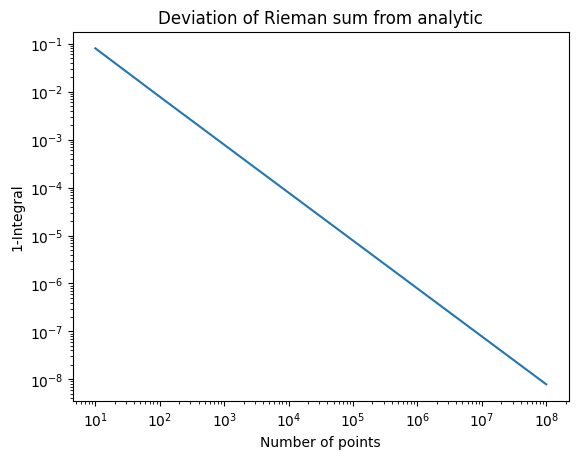

In [8]:
N=np.logspace(1,8,8)
print(N)
x=np.array([integral(f,int(n)) for n in N])  ## either f or np.sin works!
plt.plot(N,1-x)
plt.xscale('log')
plt.yscale('log')
plt.title("Deviation of Rieman sum from analytic")
plt.xlabel('Number of points')
plt.ylabel('1-Integral')
plt.show()

This works, but we get an fractional accuracy of 1e-8 with a 100M evaluations of the function.  People have figured out a number of algorithms that do significantly better- both in accuracy and in the number of evaluations.  

We start by looking at scipy.integrate

In [9]:
from scipy import integrate
help(integrate)

Help on package scipy.integrate in scipy:

NAME
    scipy.integrate

DESCRIPTION
    Integration and ODEs (:mod:`scipy.integrate`)
    
    .. currentmodule:: scipy.integrate
    
    Integrating functions, given function object
    
    .. autosummary::
       :toctree: generated/
    
       quad          -- General purpose integration
       quad_vec      -- General purpose integration of vector-valued functions
       dblquad       -- General purpose double integration
       tplquad       -- General purpose triple integration
       nquad         -- General purpose N-D integration
       fixed_quad    -- Integrate func(x) using Gaussian quadrature of order n
       quadrature    -- Integrate with given tolerance using Gaussian quadrature
       romberg       -- Integrate func using Romberg integration
       newton_cotes  -- Weights and error coefficient for Newton-Cotes integration
       qmc_quad      -- N-D integration using Quasi-Monte Carlo quadrature
       IntegrationWarnin

We will look at ODE solvers later, and go through things a step at a time. But for historical reasons, we will start with the "trapezoidal" solver.

In [10]:
help(integrate.trapezoid)

Help on function trapezoid in module scipy.integrate._quadrature:

trapezoid(y, x=None, dx=1.0, axis=-1)
    Integrate along the given axis using the composite trapezoidal rule.
    
    If `x` is provided, the integration happens in sequence along its
    elements - they are not sorted.
    
    Integrate `y` (`x`) along each 1d slice on the given axis, compute
    :math:`\int y(x) dx`.
    When `x` is specified, this integrates along the parametric curve,
    computing :math:`\int_t y(t) dt =
    \int_t y(t) \left.\frac{dx}{dt}\right|_{x=x(t)} dt`.
    
    Parameters
    ----------
    y : array_like
        Input array to integrate.
    x : array_like, optional
        The sample points corresponding to the `y` values. If `x` is None,
        the sample points are assumed to be evenly spaced `dx` apart. The
        default is None.
    dx : scalar, optional
        The spacing between sample points when `x` is None. The default is 1.
    axis : int, optional
        The axis along 

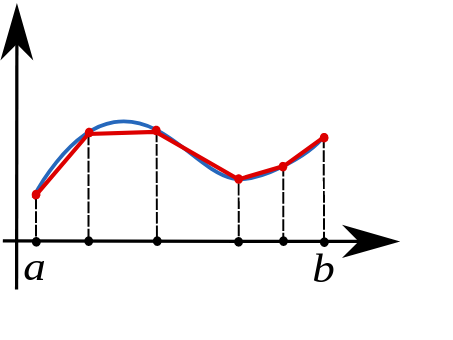

In [11]:
def trap(N):
    x=np.linspace(0,np.pi/2,N)
    return integrate.trapezoid(f(x),x=x)  #f(x) is an array with N values

In [12]:
help(integrate.trapezoid)

Help on function trapezoid in module scipy.integrate._quadrature:

trapezoid(y, x=None, dx=1.0, axis=-1)
    Integrate along the given axis using the composite trapezoidal rule.
    
    If `x` is provided, the integration happens in sequence along its
    elements - they are not sorted.
    
    Integrate `y` (`x`) along each 1d slice on the given axis, compute
    :math:`\int y(x) dx`.
    When `x` is specified, this integrates along the parametric curve,
    computing :math:`\int_t y(t) dt =
    \int_t y(t) \left.\frac{dx}{dt}\right|_{x=x(t)} dt`.
    
    Parameters
    ----------
    y : array_like
        Input array to integrate.
    x : array_like, optional
        The sample points corresponding to the `y` values. If `x` is None,
        the sample points are assumed to be evenly spaced `dx` apart. The
        default is None.
    dx : scalar, optional
        The spacing between sample points when `x` is None. The default is 1.
    axis : int, optional
        The axis along 

In [13]:
Ntrap=np.logspace(1,8,8)
xtrap=np.array([trap(int(n)) for n in Ntrap])

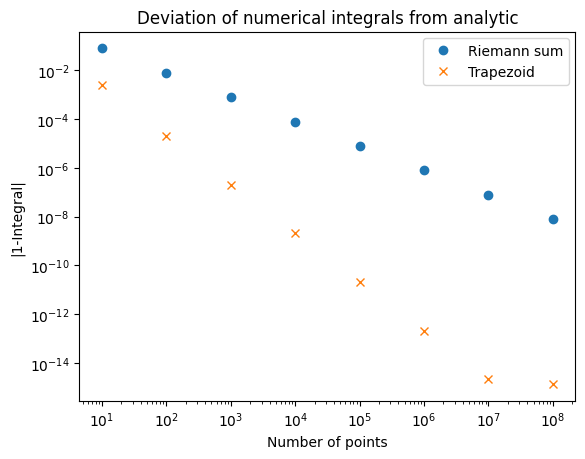

In [14]:
plt.plot(N,1-x,'o',label='Riemann sum')
plt.plot(Ntrap,abs(1-xtrap),'x',label='Trapezoid')
plt.xscale('log')
plt.yscale('log')
plt.title("Deviation of numerical integrals from analytic")
plt.xlabel('Number of points')
plt.ylabel('|1-Integral|')
plt.legend()
plt.show()

Significantly better-- does that make intuitive sense?  Why is there no difference between 10 million and 100 million points?

Trapezoidal integration would be exact for polynomials up to degree 1.  It is straightforward to find a similar formula that is exact for polynomials up to degree 2; it turns out that it is actually exact for an extra degree, due to a cancellation of the next order terms.  The mathematics we will ignore, because it doesn't teach us anything.   
We end up with a "classic" routine, Simpson's Rule:
$$\int_{x_0}^{x_2} f(x)dx=h\left[ \frac{1}{3}f_0+\frac{4}{3}f_1+\frac{1}{3}f_2\right]+ O(h^5 f^{(4)})$$

where we are integrating over an interval of size $2h$, $f_0,f_1,f_2$ refer to the values of the function at the first, second, and third points, and $f^{(4)}$ is the fourth derivative of the function at an unknown place in the interval. 

For an odd number of points, we can extend the formula by adding things together:
$$\int_{x_0}^{x_{N-1}} f(x)dx=h\left[ \frac{1}{3}f_0+\frac{4}{3}f_1+\frac{2}{3}f_2+\frac{4}{3}f_3+\frac{2}{3}f_4+...+\frac{2}{3}f_{N-3}+\frac{4}{3}f_{N-2}+\frac{1}{3}f_{N-1}\right]+ O(\frac {1}{N^4})$$

This is implemented in scipy.integrate.  This is probabaly not a great routine to use- there are better ones that we will get to soon, but is there for historical perspective.

In [15]:
help(integrate.simpson)

Help on function simpson in module scipy.integrate._quadrature:

simpson(y, *, x=None, dx=1.0, axis=-1, even=<object object at 0x70f074e413e0>)
    Integrate y(x) using samples along the given axis and the composite
    Simpson's rule. If x is None, spacing of dx is assumed.
    
    If there are an even number of samples, N, then there are an odd
    number of intervals (N-1), but Simpson's rule requires an even number
    of intervals. The parameter 'even' controls how this is handled.
    
    Parameters
    ----------
    y : array_like
        Array to be integrated.
    x : array_like, optional
        If given, the points at which `y` is sampled.
    dx : float, optional
        Spacing of integration points along axis of `x`. Only used when
        `x` is None. Default is 1.
    axis : int, optional
        Axis along which to integrate. Default is the last axis.
    even : {None, 'simpson', 'avg', 'first', 'last'}, optional
        'avg' : Average two results:
            1) u

In [16]:
def simp(N):
    x=np.linspace(0,np.pi/2,N)
    return integrate.simpson(f(x),x=x)
Nsimps=np.logspace(1,8,8)-1  #-1 to make it odd
xsimps=np.array([simp(int(n)) for n in Nsimps])
print(abs(1-xsimps))

[8.29552397e-06 3.66704223e-10 3.41948692e-14 0.00000000e+00
 0.00000000e+00 1.11022302e-16 0.00000000e+00 1.55431223e-15]


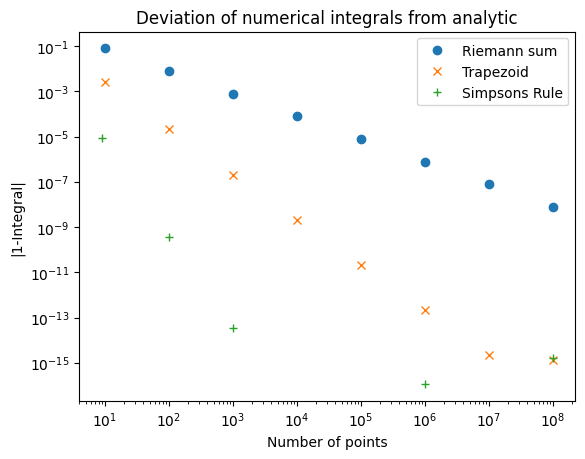

In [18]:
plt.plot(N,1-x,'o',label='Riemann sum')
plt.plot(Ntrap,abs(1-xtrap),'x',label='Trapezoid')
plt.plot(Nsimps,abs(1-xsimps),'+',label='Simpsons Rule')
plt.xscale('log')
plt.yscale('log')
plt.title("Deviation of numerical integrals from analytic")
plt.xlabel('Number of points')
plt.ylabel('|1-Integral|')
plt.legend()
plt.show()

## Romberg Integration

Romberg is the first example of a routine you should actually use-- it is generally useful for smooth functions.  It is an extension of Simpson's rule- with the idea of *Richardson's deferred approach to the limit*-  it calculates the integral for various step sizes and extrapolates to the point where the step sizes are zero.  Because it doubles the number of points it uses every step, it requires $2^k+1$ points if we precalculate the function the way we have been doing(integrate.romb).  We can also call it giving the function as the argument- integrate.romberg.

In [19]:
help(integrate.romb)

Help on function romb in module scipy.integrate._quadrature:

romb(y, dx=1.0, axis=-1, show=False)
    Romberg integration using samples of a function.
    
    Parameters
    ----------
    y : array_like
        A vector of ``2**k + 1`` equally-spaced samples of a function.
    dx : float, optional
        The sample spacing. Default is 1.
    axis : int, optional
        The axis along which to integrate. Default is -1 (last axis).
    show : bool, optional
        When `y` is a single 1-D array, then if this argument is True
        print the table showing Richardson extrapolation from the
        samples. Default is False.
    
    Returns
    -------
    romb : ndarray
        The integrated result for `axis`.
    
    See Also
    --------
    quad : adaptive quadrature using QUADPACK
    romberg : adaptive Romberg quadrature
    quadrature : adaptive Gaussian quadrature
    fixed_quad : fixed-order Gaussian quadrature
    dblquad : double integrals
    tplquad : triple integral

In [20]:
def romb(k):
    x=np.linspace(0,np.pi/2,2**k+1)
    return integrate.romb(f(x),x[1]-x[0])
kromb=np.linspace(1,10)
Nromb=2**kromb+1
xromb=np.array([romb(int(k)) for k in kromb])

In [21]:
xromb

array([1.00227988, 1.00227988, 1.00227988, 1.00227988, 1.00227988,
       1.00227988, 0.99999157, 0.99999157, 0.99999157, 0.99999157,
       0.99999157, 1.00000001, 1.00000001, 1.00000001, 1.00000001,
       1.00000001, 1.00000001, 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ])

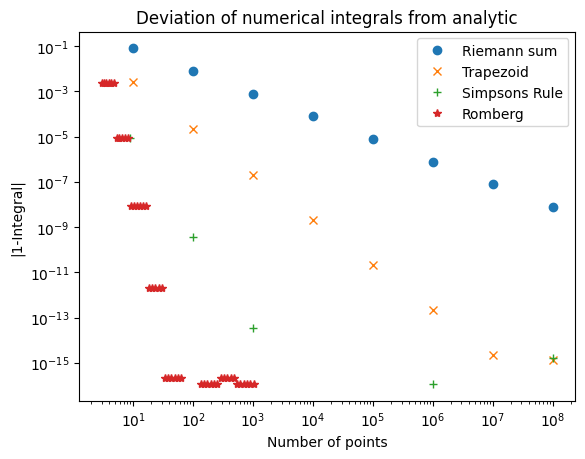

In [23]:
plt.plot(N,1-x,'o',label='Riemann sum')
plt.plot(Ntrap,abs(1-xtrap),'x',label='Trapezoid')
plt.plot(Nsimps,abs(1-xsimps),'+',label='Simpsons Rule')
plt.plot(Nromb,abs(1-xromb),'*',label='Romberg')
plt.xscale('log')
plt.yscale('log')
plt.title("Deviation of numerical integrals from analytic")
plt.xlabel('Number of points')
plt.ylabel('|1-Integral|')
plt.legend()
plt.show()

Notice that we get down to double precision accuracy with 65 function evaluations; past that we can't improve.


Redo things, letting the algorithm control the number of function calls.

In [24]:
help(integrate.romberg)

Help on function romberg in module scipy.integrate._quadrature:

romberg(function, a, b, args=(), tol=1.48e-08, rtol=1.48e-08, show=False, divmax=10, vec_func=False)
    Romberg integration of a callable function or method.
    
    .. deprecated:: 1.12.0
    
          This function is deprecated as of SciPy 1.12.0 and will be removed
          in SciPy 1.15.0. Please use `scipy.integrate.quad` instead.
    
    Returns the integral of `function` (a function of one variable)
    over the interval (`a`, `b`).
    
    If `show` is 1, the triangular array of the intermediate results
    will be printed. If `vec_func` is True (default is False), then
    `function` is assumed to support vector arguments.
    
    Parameters
    ----------
    function : callable
        Function to be integrated.
    a : float
        Lower limit of integration.
    b : float
        Upper limit of integration.
    
    Returns
    -------
    results : float
        Result of the integration.
    
    O

## Quadrature

Probably the "go-to" routine for numerical integrals should be quad-- which does one better (but perhaps not significantly so for smooth functions) by picking the x-values where the function is evaluated, and returns an estimate of the accuracy.  There are several quad functions in scipy- including ones for evaluating two (integrate.dblquad) and three(integrate.tplquad) dimensional functions, as well as vector functions(integrate.quad_vec).  

In [25]:
help(integrate.quad)

Help on function quad in module scipy.integrate._quadpack_py:

quad(func, a, b, args=(), full_output=0, epsabs=1.49e-08, epsrel=1.49e-08, limit=50, points=None, weight=None, wvar=None, wopts=None, maxp1=50, limlst=50, complex_func=False)
    Compute a definite integral.
    
    Integrate func from `a` to `b` (possibly infinite interval) using a
    technique from the Fortran library QUADPACK.
    
    Parameters
    ----------
    func : {function, scipy.LowLevelCallable}
        A Python function or method to integrate. If `func` takes many
        arguments, it is integrated along the axis corresponding to the
        first argument.
    
        If the user desires improved integration performance, then `f` may
        be a `scipy.LowLevelCallable` with one of the signatures::
    
            double func(double x)
            double func(double x, void *user_data)
            double func(int n, double *xx)
            double func(int n, double *xx, void *user_data)
    
        Th

In [26]:
ncalls=0
print(integrate.quad(f,0,np.pi/2), '  Ncalls=',ncalls)

(0.9999999999999999, 1.1102230246251564e-14)   Ncalls= 0


There are other routines that are sometimes useful- like tanh integration to deal with singularities at end points- and if you run into a numerical situation like that *read the documentation*.  

# Application-- numerical calculation of $\pi$

If we know how to numerically integrate, to find $\pi$ we can integrate a semicircle, which we know has an area $\frac{\pi r^2}{2}$.  We take $r=1$; then $x^2+y^2=1$ and $y=\sqrt{1-x^2}.$  Thus $$\pi=2\int_{-1}^1\sqrt{1-x^2}dx.$$

In [27]:
def circ(x):
    return 2*np.sqrt(1-x*x)
print('pi is', integrate.quad(circ,-1.0,1.0))
print('pi is', integrate.quad(circ,-1.0,1.0,epsabs=2e-14,epsrel=2e-14))

pi is (3.1415926535897967, 2.000470900043183e-09)
pi is (3.1415926535897913, 5.1514348342607263e-14)


In [28]:
print('difference from precise pi is', integrate.quad(circ,-1.0,1.0,epsabs=2e-14,epsrel=2e-14)[0]-np.pi)

difference from precise pi is -1.7763568394002505e-15
